# Model Evaluation: Comparing Logistic Regression, SVM, Neural Network, Random Forest

We compare two classifiers:
- **Logistic Regression**
- **SVM**
- **MLP Classifier (Neural Network)**
- **Random Forest**


Using metrics: Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

## Step 1: Load the Data

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)

# Normalize (Standardize) features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Step 2: Train the Models

In [25]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=10)
lr_model.fit(X_train, y_train)

# from pprint import pprint
# pprint(lr_model.get_params())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=10)

In [26]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, max_iter=10)
svm_model.fit(X_train, y_train)

# from pprint import pprint
# pprint(svm_model.get_params())

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


SVC(max_iter=10, probability=True)

In [27]:
from sklearn.neural_network import MLPClassifier

nn_model = MLPClassifier(hidden_layer_sizes=(50,), max_iter=10, random_state=42)
nn_model.fit(X_train, y_train)

# from pprint import pprint
# pprint(nn_model.get_params())

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(50,), max_iter=10, random_state=42)

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# from pprint import pprint
# pprint(rf_model.get_params())

RandomForestClassifier(random_state=42)

## Step 3: Evaluation Metrics

### What is Accuracy?

**Accuracy** is the proportion of correct predictions:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

Can be misleading if classes are imbalanced.

In [28]:
from sklearn.metrics import accuracy_score


lr_acc = accuracy_score(y_test, lr_model.predict(X_test))
svm_acc = accuracy_score(y_test, svm_model.predict(X_test))
nn_acc = accuracy_score(y_test, nn_model.predict(X_test))
rf_acc = accuracy_score(y_test, rf_model.predict(X_test))

print(f"Logistic egression Accuracy: {lr_acc:.2f}")
print(f"SVM Accuracy: {svm_acc:.2f}")
print(f"Neural Network Accuracy: {nn_acc:.2f}")
print(f"Random Forest Accuracy: {rf_acc:.2f}")

Logistic egression Accuracy: 0.98
SVM Accuracy: 0.95
Neural Network Accuracy: 0.93
Random Forest Accuracy: 0.96


### What are Precision, Recall and F1 Score?

- **Precision**: $\frac{TP}{TP + FP}$  
- **Recall**: $\frac{TP}{TP + FN}$  
- **F1 Score**: Harmonic mean of precision and recall  

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
$$

In [29]:
from sklearn.metrics import precision_score, recall_score, f1_score

for name, model in [("Logistic Regression", lr_model), ("SVM", svm_model),("Neural Network", nn_model), ("Random Forest", rf_model)]:
    y_pred = model.predict(X_test)
    print(f"\n{name} Metrics:")
    print(f"Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.2f}")


Logistic Regression Metrics:
Precision: 0.98
Recall: 0.98
F1 Score: 0.98

SVM Metrics:
Precision: 0.93
Recall: 0.99
F1 Score: 0.96

Neural Network Metrics:
Precision: 0.95
Recall: 0.94
F1 Score: 0.94

Random Forest Metrics:
Precision: 0.96
Recall: 0.97
F1 Score: 0.97


### What is a Confusion Matrix?

A **confusion matrix** shows the breakdown of correct and incorrect classifications.

|                 | Predicted Negative | Predicted Positive |
|-----------------|--------------------|--------------------|
| Actual Negative | True Negative (TN) | False Positive (FP)|
| Actual Positive | False Negative (FN)| True Positive (TP) |

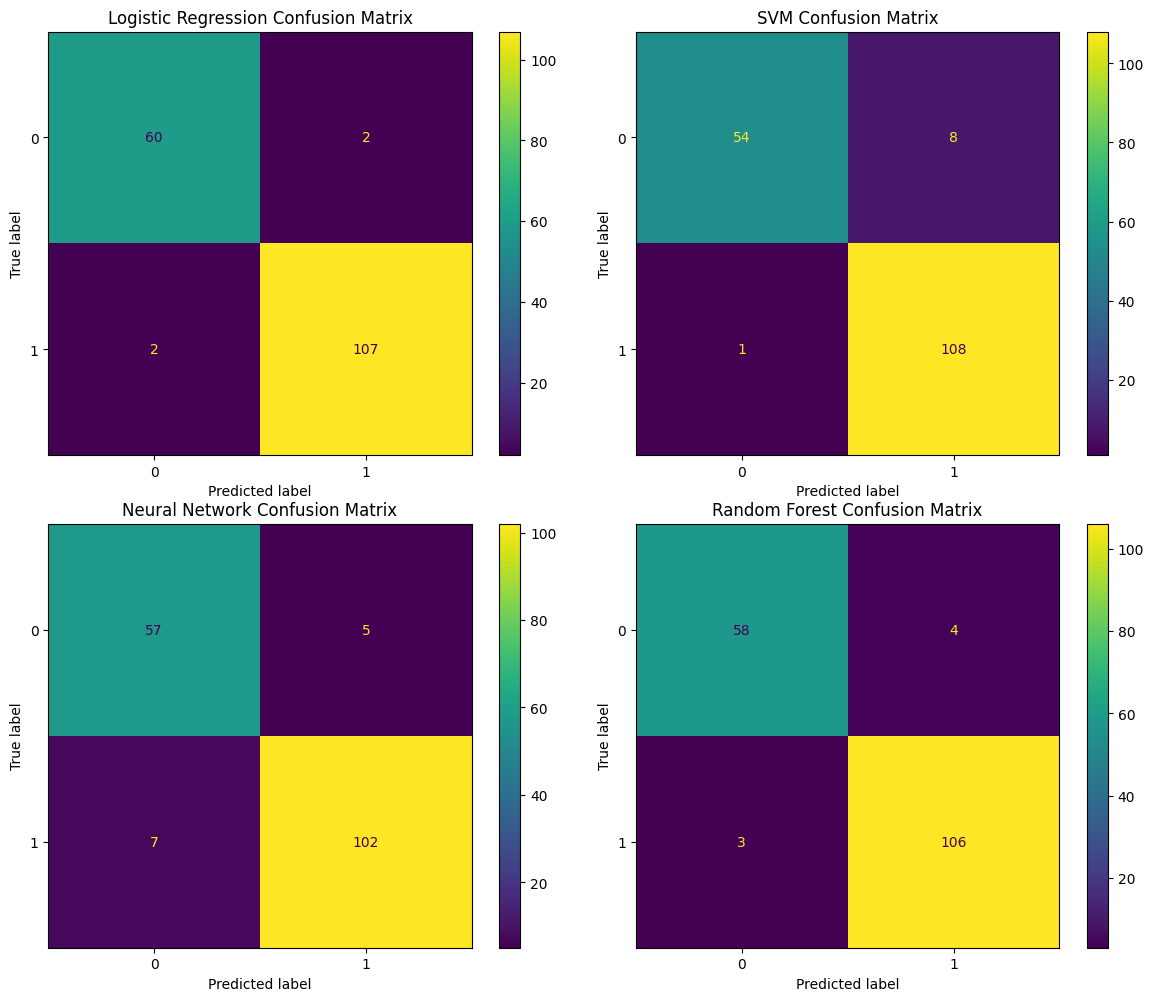

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12, 10))

ConfusionMatrixDisplay.from_estimator(lr_model, X_test, y_test, ax=axs[0, 0])
axs[0, 0].set_title("Logistic Regression Confusion Matrix")
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, ax=axs[0, 1])
axs[0, 1].set_title("SVM Confusion Matrix")
ConfusionMatrixDisplay.from_estimator(nn_model, X_test, y_test, ax=axs[1, 0])
axs[1, 0].set_title("Neural Network Confusion Matrix")
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=axs[1, 1])
axs[1, 1].set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### What is the ROC Curve?

ROC = Receiver Operating Characteristic Curve

- Plots TPR vs FPR
- **AUC** = Area Under the ROC Curve
Closer to 1 = better model.

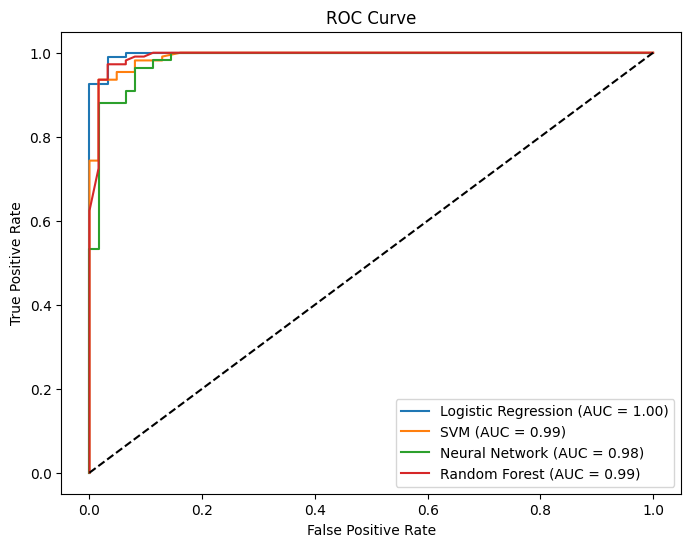

In [31]:
from sklearn.metrics import roc_curve, auc

lr_probs = lr_model.predict_proba(X_test)[:, 1]
svm_probs = svm_model.predict_proba(X_test)[:, 1]
nn_probs = nn_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

lr_auc = auc(lr_fpr, lr_tpr)
svm_auc = auc(svm_fpr, svm_tpr)
nn_auc = auc(nn_fpr, nn_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_auc:.2f})")
plt.plot(svm_fpr, svm_tpr, label=f"SVM (AUC = {svm_auc:.2f})")
plt.plot(nn_fpr, nn_tpr, label=f"Neural Network (AUC = {nn_auc:.2f})")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_auc:.2f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Conclusion???